# Exploratory Data Analysis for Goalkeepers

This notebook provides a comprehensive analysis of goalkeeper performance data to understand key metrics, patterns, and insights for predicting player market values.

## 1. Import Required Libraries

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
try:
    plt.style.use('seaborn-v0_8')
except:
    plt.style.use('seaborn')
sns.set_palette("husl")

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Datasets

In [48]:
# Load the goalkeepers dataset
gk_df = pd.read_csv('../Data/GK-FBREF.csv')

# Load the market values dataset
market_values_df = pd.read_csv('../Data/PlayersTM.csv')

print("Goalkeepers dataset shape:", gk_df.shape)
print("Market values dataset shape:", market_values_df.shape)
print("\nFirst few rows of goalkeepers dataset:")
print(gk_df.head())

Goalkeepers dataset shape: (201, 25)
Market values dataset shape: (2749, 2)

First few rows of goalkeepers dataset:
              Player Nation Pos            Team  Age  Born  MP  Starts    Min  \
0            Alisson    BRA  GK       Liverpool   31  1992  28      28  2,508   
1    Alphonse Areola    FRA  GK        West Ham   31  1993  26      25  2,260   
2  Kepa Arrizabalaga    ESP  GK     Bournemouth   29  1994  31      31  2,790   
3     Brandon Austin    ENG  GK       Tottenham   25  1999   1       1     90   
4     Altay Bayındır    TUR  GK  Manchester Utd   26  1998   4       4    360   

    90s  GA  GA90  SoTA  Saves  Save%   W  D   L  CS   CS%  PKatt  PKA  PKsv  \
0  27.9  29  1.04   100     73   72.0  18  7   3   9  32.1      1    1     0   
1  25.1  41  1.63   115     77   64.3   5  7  13   5  20.0      0    0     0   
2  31.0  39  1.26   134     95   73.9  13  7  11   8  25.8      4    4     0   
3   1.0   2  2.00     4      2   50.0   0  0   1   0   0.0      0    0     0 

## 3. Initial Data Exploration

In [49]:
# Display basic information about the goalkeepers dataset
print("=== GOALKEEPERS DATASET INFO ===")
print(gk_df.info())
print("\n=== DESCRIPTIVE STATISTICS ===")
print(gk_df.describe())

=== GOALKEEPERS DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 25 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player   201 non-null    object 
 1   Nation   201 non-null    object 
 2   Pos      201 non-null    object 
 3   Team     201 non-null    object 
 4   Age      201 non-null    int64  
 5   Born     201 non-null    int64  
 6   MP       201 non-null    int64  
 7   Starts   201 non-null    int64  
 8   Min      201 non-null    object 
 9   90s      201 non-null    float64
 10  GA       201 non-null    int64  
 11  GA90     201 non-null    float64
 12  SoTA     201 non-null    int64  
 13  Saves    201 non-null    int64  
 14  Save%    201 non-null    float64
 15  W        201 non-null    int64  
 16  D        201 non-null    int64  
 17  L        201 non-null    int64  
 18  CS       201 non-null    int64  
 19  CS%      201 non-null    float64
 20  PKatt    201 non-null

In [50]:
# Check for missing values
print("=== MISSING VALUES ===")
missing_values = gk_df.isnull().sum()
missing_percentage = (missing_values / len(gk_df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Values'] > 0])

=== MISSING VALUES ===
         Missing Values  Percentage
PKSave%              55   27.363184


## 4. Data Cleaning and Preprocessing

In [51]:
# Clean the data
# Convert 'Min' column to numeric (remove commas)
gk_df['Min'] = gk_df['Min'].str.replace(',', '').astype(float)

# Handle missing values in Save% and PKSave%
gk_df['Save%'] = pd.to_numeric(gk_df['Save%'], errors='coerce')
gk_df['PKSave%'] = pd.to_numeric(gk_df['PKSave%'], errors='coerce')

# Fill missing values with median for numerical columns
numerical_columns = gk_df.select_dtypes(include=[np.number]).columns
gk_df[numerical_columns] = gk_df[numerical_columns].fillna(gk_df[numerical_columns].median())

print("Data cleaned successfully!")
print(f"Dataset shape after cleaning: {gk_df.shape}")
print(f"Columns: {list(gk_df.columns)}")

Data cleaned successfully!
Dataset shape after cleaning: (201, 25)
Columns: ['Player', 'Nation', 'Pos', 'Team', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt', 'PKA', 'PKsv', 'PKm', 'PKSave%']


## 5. Age Distribution Analysis

Age Statistics:
count    201.000000
mean      27.930348
std        4.655655
min       18.000000
25%       24.000000
50%       28.000000
75%       31.000000
max       41.000000
Name: Age, dtype: float64


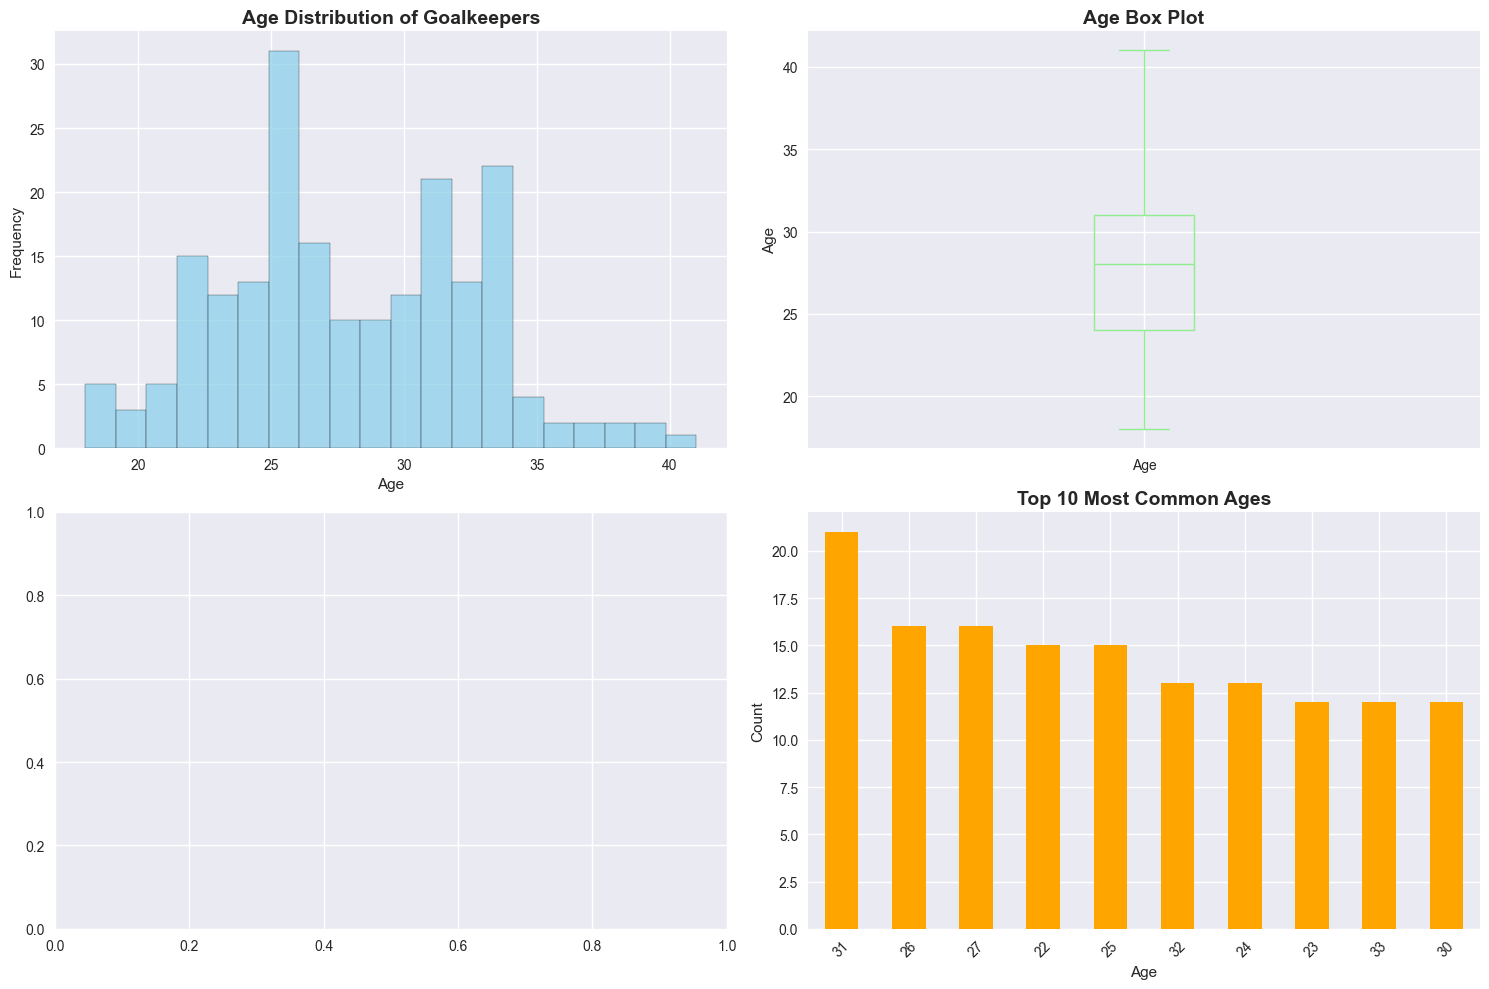

In [52]:
# Age distribution analysis
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.hist(gk_df['Age'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Age Distribution of Goalkeepers', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
gk_df['Age'].plot(kind='box', color='lightgreen')
plt.title('Age Box Plot', fontsize=14, fontweight='bold')
plt.ylabel('Age')

plt.subplot(2, 2, 3)
age_stats = gk_df['Age'].describe()
print("Age Statistics:")
print(age_stats)

plt.subplot(2, 2, 4)
gk_df['Age'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Most Common Ages', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6. Performance Metrics Analysis

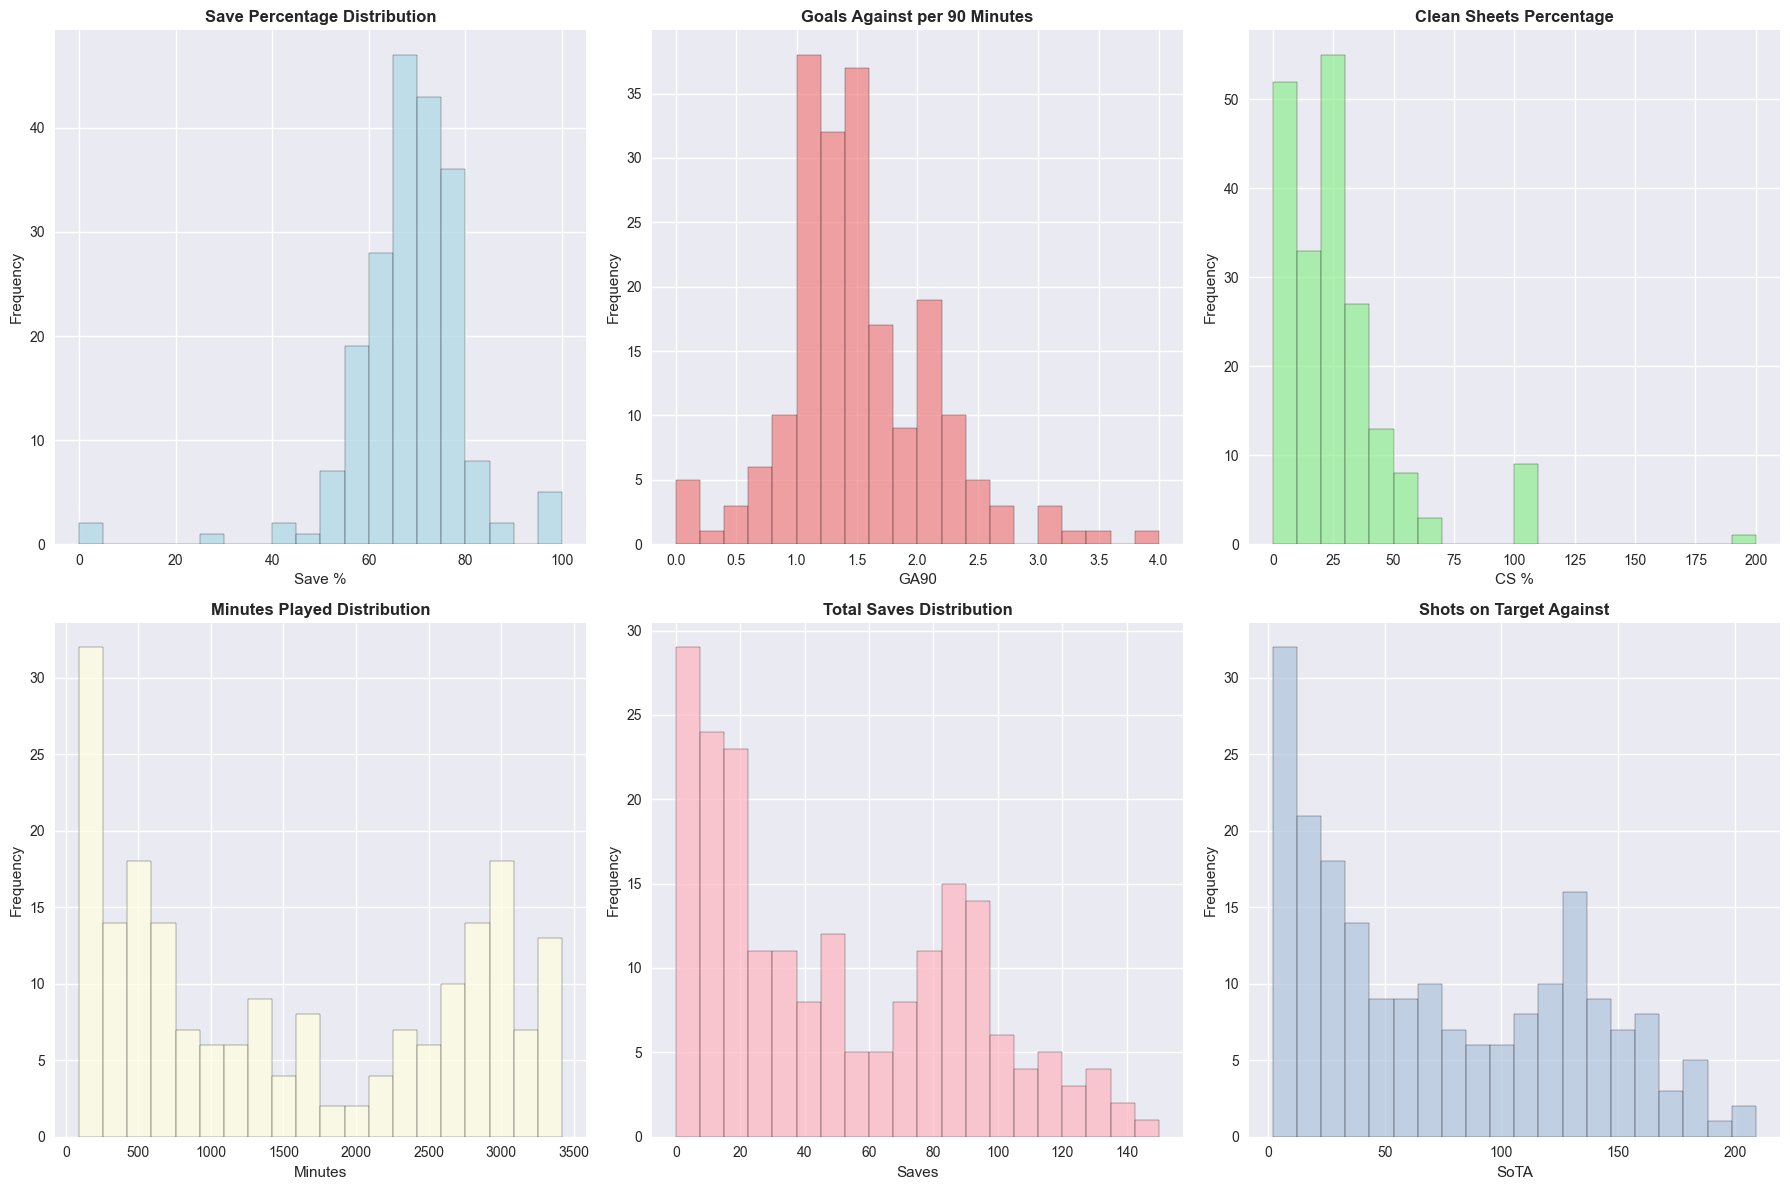

In [53]:
# Performance metrics analysis
plt.figure(figsize=(18, 12))

# Save percentage distribution
plt.subplot(2, 3, 1)
plt.hist(gk_df['Save%'], bins=20, edgecolor='black', alpha=0.7, color='lightblue')
plt.title('Save Percentage Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Save %')
plt.ylabel('Frequency')

# Goals against per 90 minutes
plt.subplot(2, 3, 2)
plt.hist(gk_df['GA90'], bins=20, edgecolor='black', alpha=0.7, color='lightcoral')
plt.title('Goals Against per 90 Minutes', fontsize=12, fontweight='bold')
plt.xlabel('GA90')
plt.ylabel('Frequency')

# Clean sheets percentage
plt.subplot(2, 3, 3)
plt.hist(gk_df['CS%'], bins=20, edgecolor='black', alpha=0.7, color='lightgreen')
plt.title('Clean Sheets Percentage', fontsize=12, fontweight='bold')
plt.xlabel('CS %')
plt.ylabel('Frequency')

# Minutes played
plt.subplot(2, 3, 4)
plt.hist(gk_df['Min'], bins=20, edgecolor='black', alpha=0.7, color='lightyellow')
plt.title('Minutes Played Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Minutes')
plt.ylabel('Frequency')

# Saves
plt.subplot(2, 3, 5)
plt.hist(gk_df['Saves'], bins=20, edgecolor='black', alpha=0.7, color='lightpink')
plt.title('Total Saves Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Saves')
plt.ylabel('Frequency')

# Shots on target against
plt.subplot(2, 3, 6)
plt.hist(gk_df['SoTA'], bins=20, edgecolor='black', alpha=0.7, color='lightsteelblue')
plt.title('Shots on Target Against', fontsize=12, fontweight='bold')
plt.xlabel('SoTA')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

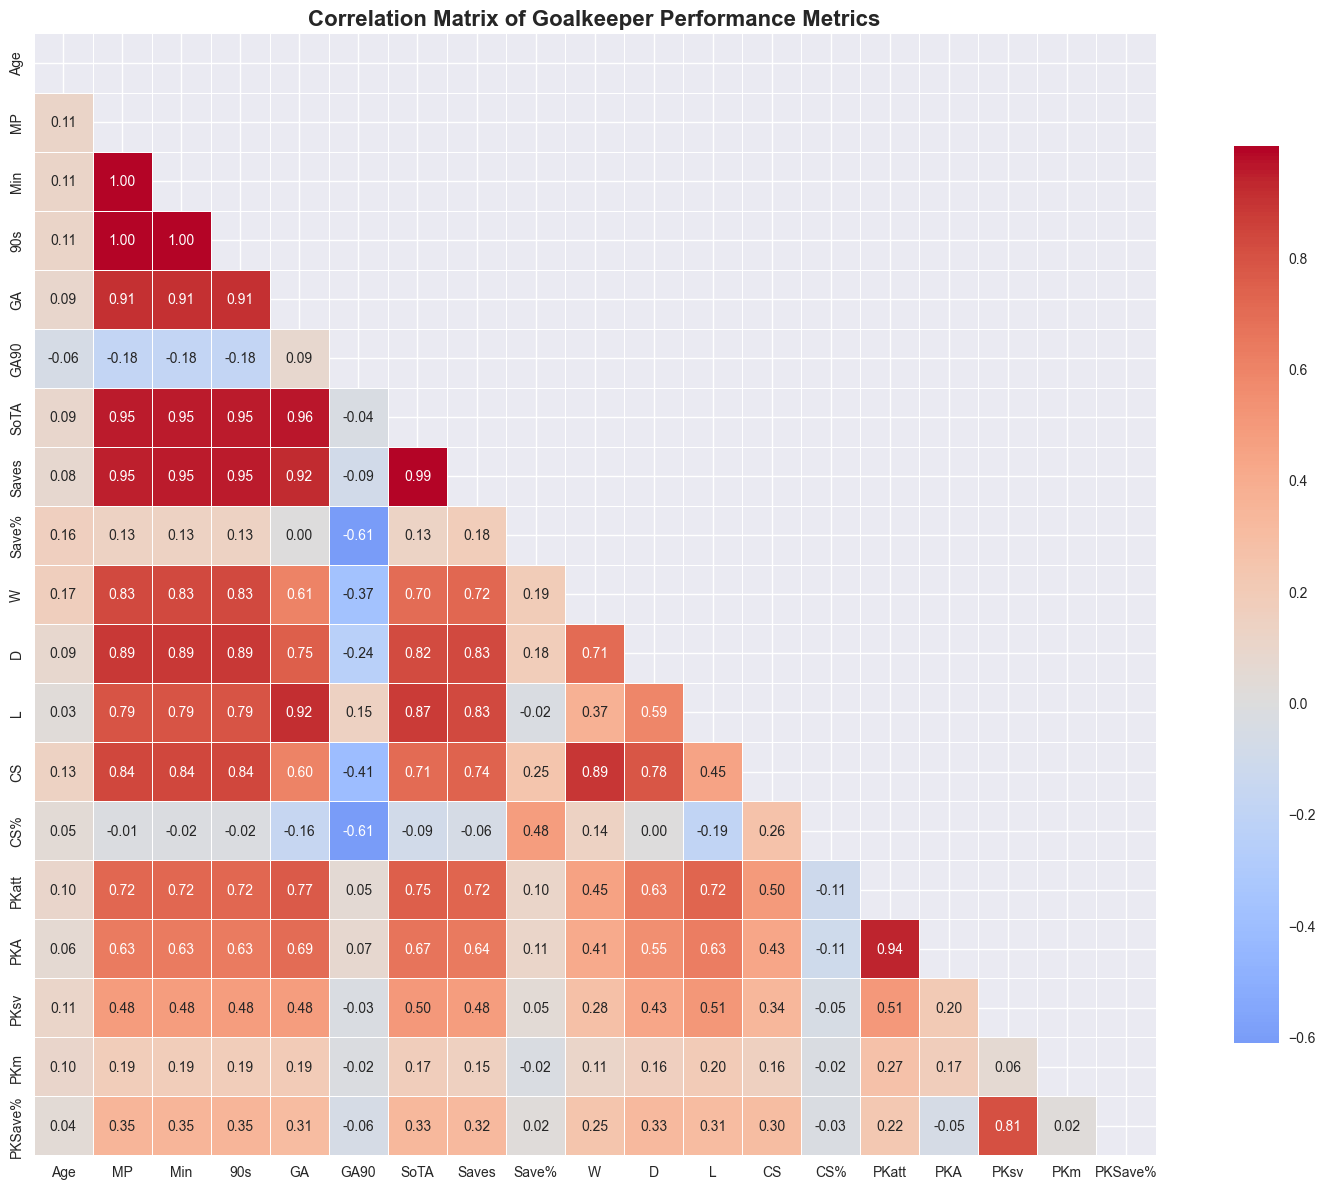


Top 10 Strongest Correlations:
90s    Min      0.999990
Min    90s      0.999990
       MP       0.999647
MP     Min      0.999647
       90s      0.999636
90s    MP       0.999636
Saves  SoTA     0.991871
SoTA   Saves    0.991871
       GA       0.962915
GA     SoTA     0.962915
dtype: float64


In [54]:
# Select numerical columns for correlation analysis
numerical_cols = ['Age', 'MP', 'Min', '90s', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 
                  'W', 'D', 'L', 'CS', 'CS%', 'PKatt', 'PKA', 'PKsv', 'PKm', 'PKSave%']

# Create correlation matrix
correlation_matrix = gk_df[numerical_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.2f')
plt.title('Correlation Matrix of Goalkeeper Performance Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Show top correlations
print("\nTop 10 Strongest Correlations:")
correlations = correlation_matrix.unstack()
correlations = correlations[correlations != 1.0]  # Remove self-correlations
correlations = correlations.sort_values(ascending=False)
print(correlations.head(10))

## 8. Team Analysis

Team-wise Goalkeeper Statistics:
                Number of GKs  Avg Save%  Avg GA90  Avg CS%  Total Minutes
Team                                                                      
Tottenham                   4      62.32      1.88    11.92         3420.0
Alavés                      3      71.20      1.34    41.67         3419.0
Athletic Club               3      75.37      1.01    27.77         3417.0
Atalanta                    3      84.60      0.67    57.17         3420.0
Bournemouth                 3      79.50      1.09    15.27         3420.0
Betis                       3      64.17      1.29    14.17         3420.0
Bayern Munich               3      51.53      1.28    28.03         2970.0
Barcelona                   3      66.70      1.05    30.83         3420.0
Empoli                      3      58.03      2.20     6.27         3420.0
Genoa                       3      73.53      1.46    16.27         3392.0
Como                        3      66.87      1.52    14.83        

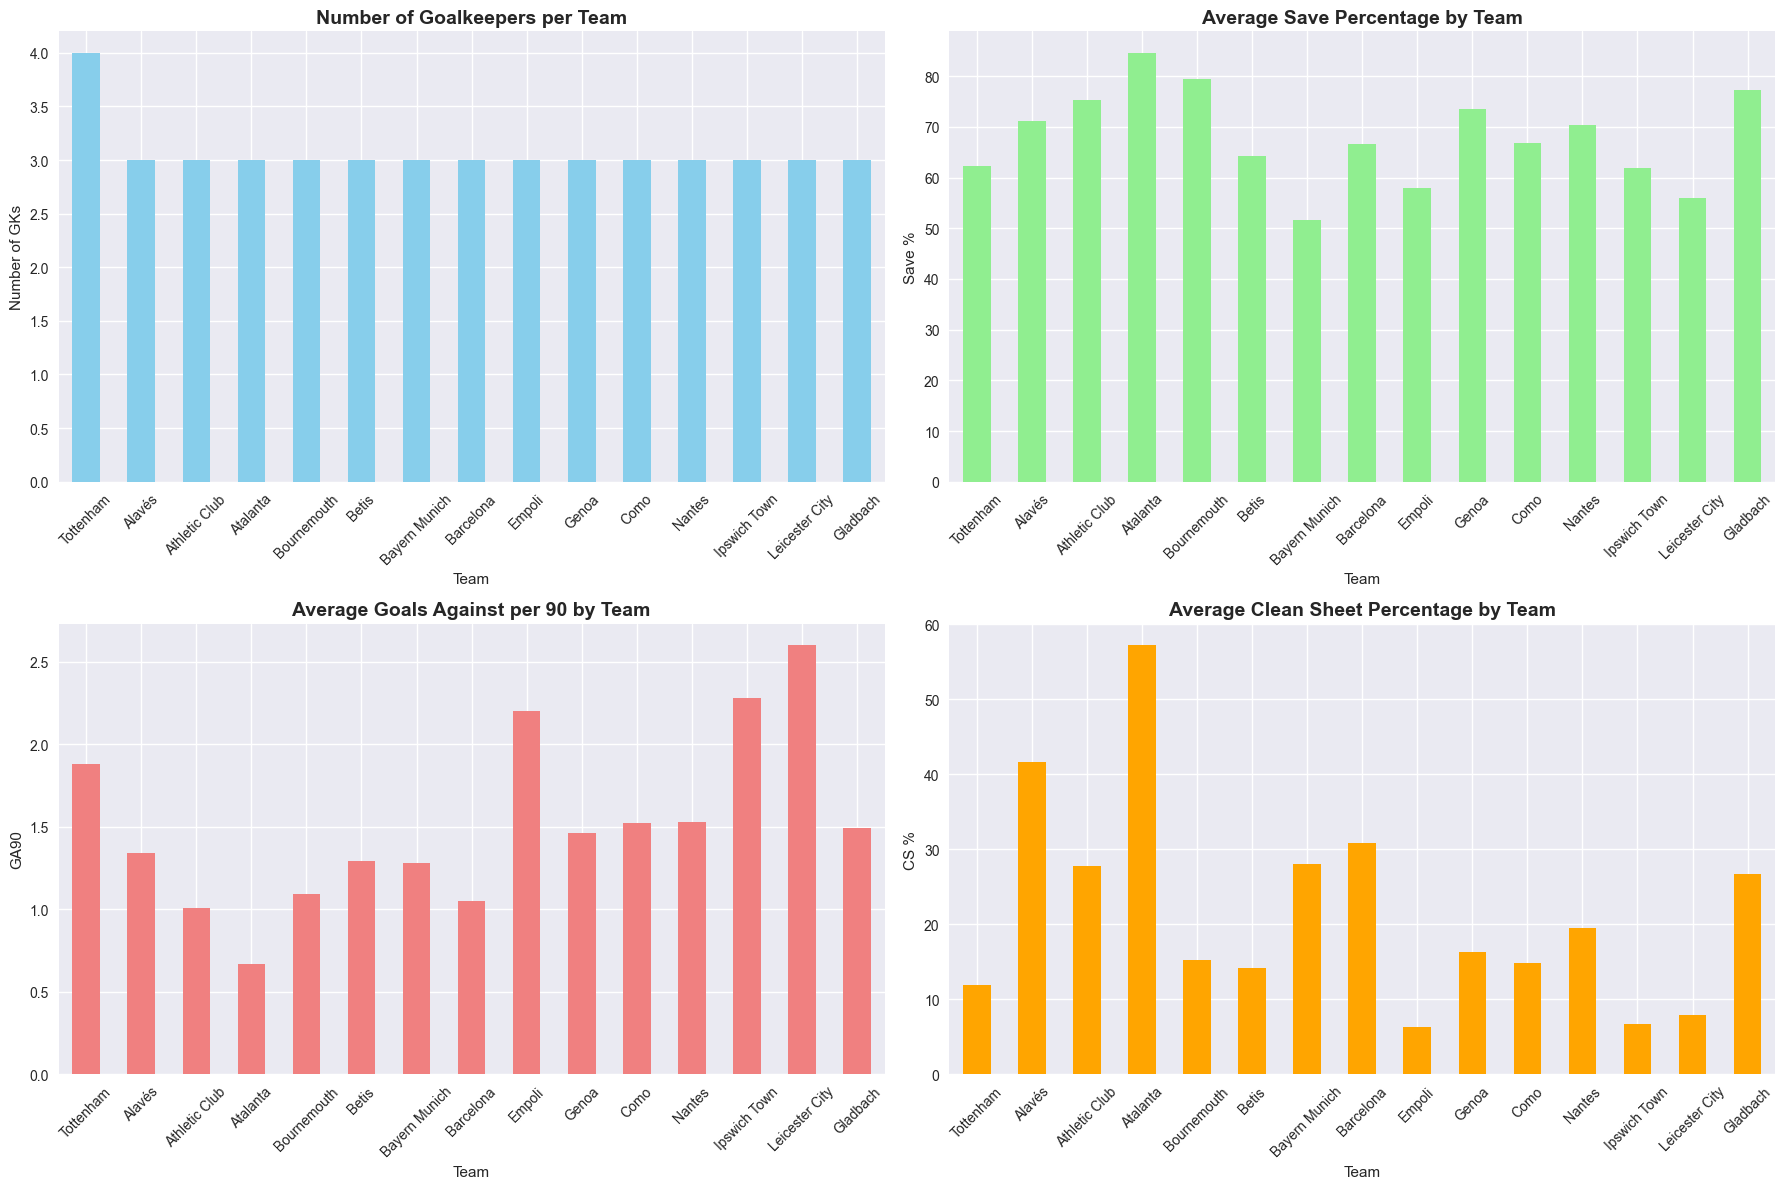

In [55]:
# Team analysis
team_stats = gk_df.groupby('Team').agg({
    'Player': 'count',
    'Save%': 'mean',
    'GA90': 'mean',
    'CS%': 'mean',
    'Min': 'sum'
}).round(2)

team_stats.columns = ['Number of GKs', 'Avg Save%', 'Avg GA90', 'Avg CS%', 'Total Minutes']
team_stats = team_stats.sort_values('Number of GKs', ascending=False)

print("Team-wise Goalkeeper Statistics:")
print(team_stats.head(15))

# Visualize team performance
plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
team_stats['Number of GKs'].head(15).plot(kind='bar', color='skyblue')
plt.title('Number of Goalkeepers per Team', fontsize=14, fontweight='bold')
plt.xlabel('Team')
plt.ylabel('Number of GKs')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
team_stats['Avg Save%'].head(15).plot(kind='bar', color='lightgreen')
plt.title('Average Save Percentage by Team', fontsize=14, fontweight='bold')
plt.xlabel('Team')
plt.ylabel('Save %')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
team_stats['Avg GA90'].head(15).plot(kind='bar', color='lightcoral')
plt.title('Average Goals Against per 90 by Team', fontsize=14, fontweight='bold')
plt.xlabel('Team')
plt.ylabel('GA90')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
team_stats['Avg CS%'].head(15).plot(kind='bar', color='orange')
plt.title('Average Clean Sheet Percentage by Team', fontsize=14, fontweight='bold')
plt.xlabel('Team')
plt.ylabel('CS %')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 9. Nationality Analysis

Top 15 Nations by Number of Goalkeepers:
        Number of GKs  Avg Save%  Avg GA90  Avg CS%  Avg Age
Nation                                                      
ESP                30      67.69      1.26    26.65    27.13
GER                26      67.13      1.57    25.06    28.50
ITA                25      68.84      1.39    30.30    27.68
FRA                16      67.76      1.68    19.33    28.25
ENG                13      65.55      1.92    17.52    29.92
POL                 7      68.09      1.38    25.57    28.86
ARG                 7      75.33      1.19    40.50    31.00
BRA                 5      75.26      1.16    27.68    28.60
POR                 5      67.88      1.74    20.16    31.60
SUI                 5      72.90      1.39    22.74    29.80
SRB                 5      77.00      1.27    26.54    25.80
NED                 4      68.38      1.61    20.17    30.00
BEL                 3      68.67      1.36    23.63    28.67
DEN                 3      67.83      1.67  

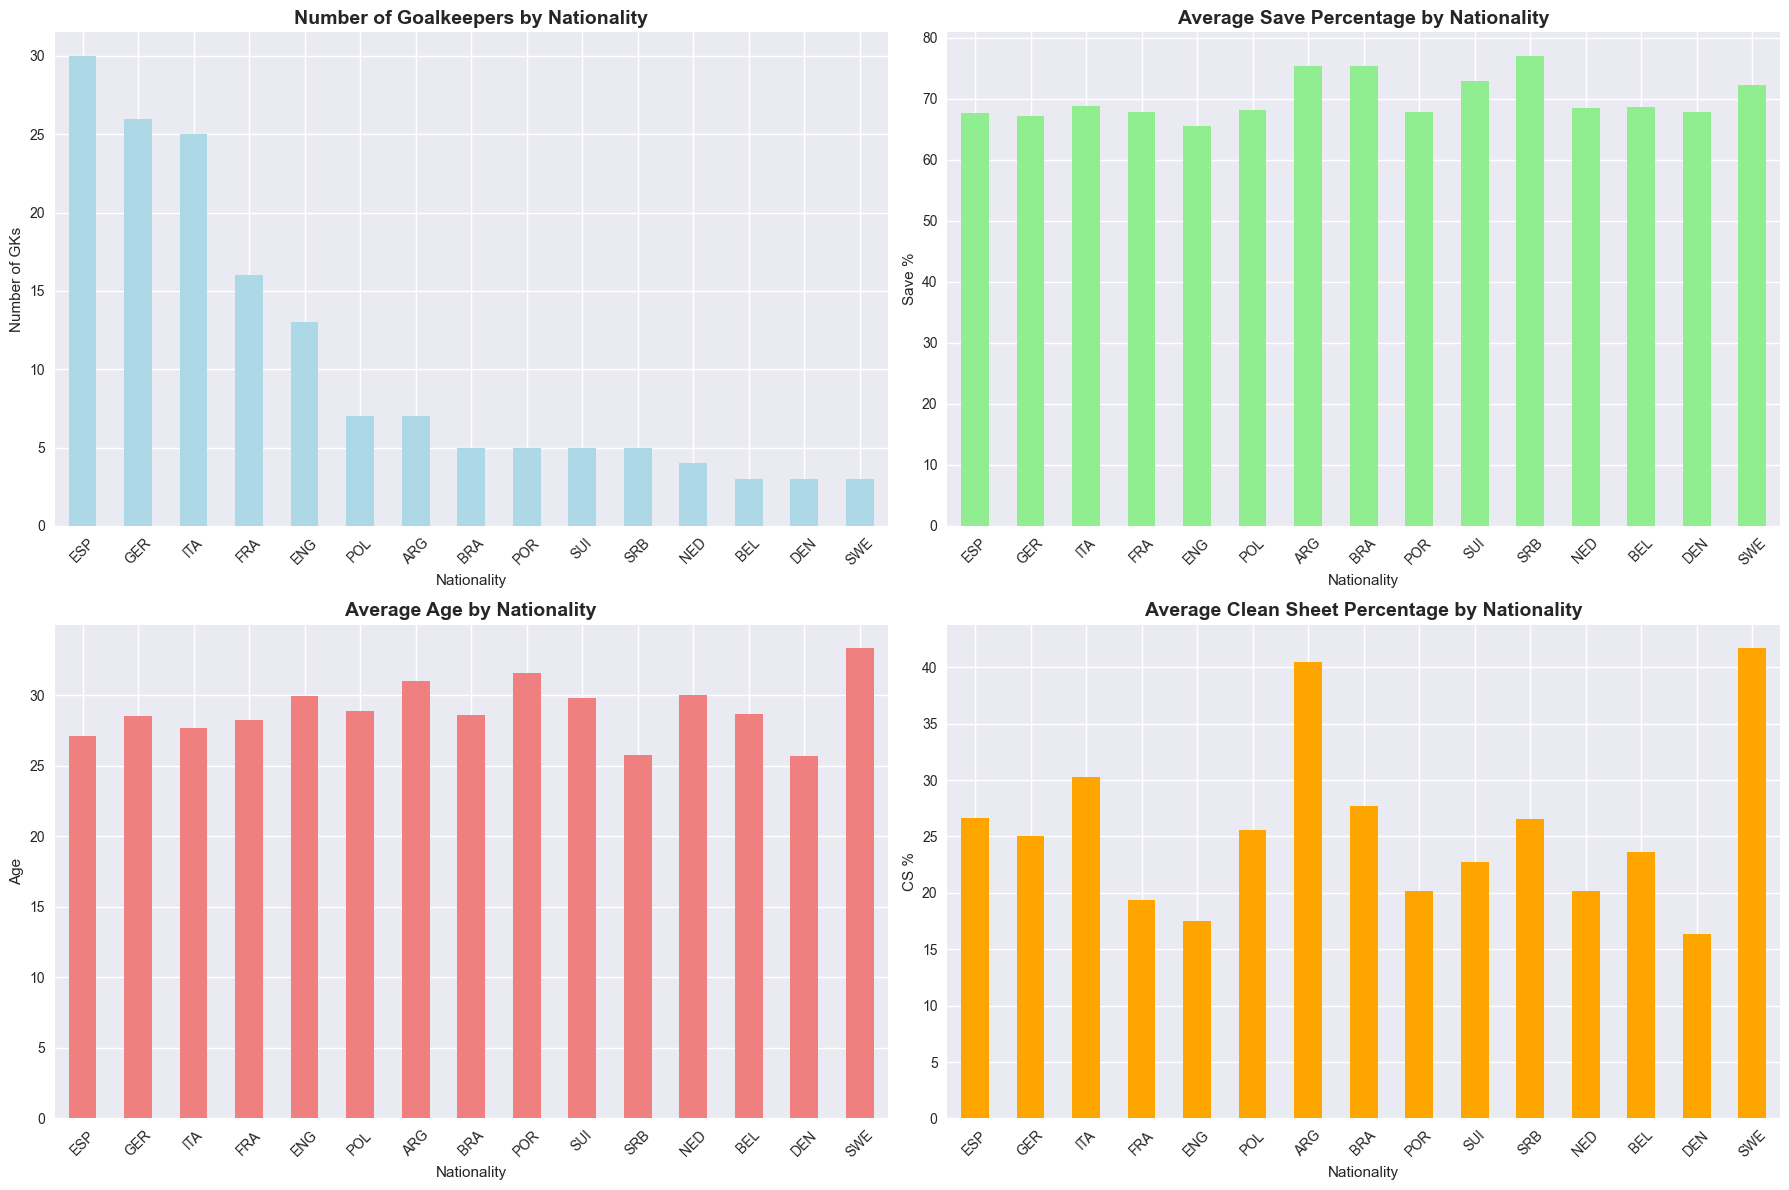

In [56]:
# Nationality analysis
nationality_stats = gk_df.groupby('Nation').agg({
    'Player': 'count',
    'Save%': 'mean',
    'GA90': 'mean',
    'CS%': 'mean',
    'Age': 'mean'
}).round(2)

nationality_stats.columns = ['Number of GKs', 'Avg Save%', 'Avg GA90', 'Avg CS%', 'Avg Age']
nationality_stats = nationality_stats.sort_values('Number of GKs', ascending=False)

print("Top 15 Nations by Number of Goalkeepers:")
print(nationality_stats.head(15))

# Visualize nationality distribution
plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
nationality_stats['Number of GKs'].head(15).plot(kind='bar', color='lightblue')
plt.title('Number of Goalkeepers by Nationality', fontsize=14, fontweight='bold')
plt.xlabel('Nationality')
plt.ylabel('Number of GKs')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
nationality_stats['Avg Save%'].head(15).plot(kind='bar', color='lightgreen')
plt.title('Average Save Percentage by Nationality', fontsize=14, fontweight='bold')
plt.xlabel('Nationality')
plt.ylabel('Save %')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
nationality_stats['Avg Age'].head(15).plot(kind='bar', color='lightcoral')
plt.title('Average Age by Nationality', fontsize=14, fontweight='bold')
plt.xlabel('Nationality')
plt.ylabel('Age')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
nationality_stats['Avg CS%'].head(15).plot(kind='bar', color='orange')
plt.title('Average Clean Sheet Percentage by Nationality', fontsize=14, fontweight='bold')
plt.xlabel('Nationality')
plt.ylabel('CS %')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 10. Top Performers Analysis

In [57]:
# Filter goalkeepers with minimum playing time (at least 10 matches)
min_matches = 10
qualified_gks = gk_df[gk_df['MP'] >= min_matches].copy()

print(f"Goalkeepers with at least {min_matches} matches: {len(qualified_gks)}")

# Top performers in different categories
print("\n=== TOP 10 GOALKEEPERS BY SAVE PERCENTAGE ===")
top_save_pct = qualified_gks.nlargest(10, 'Save%')[['Player', 'Team', 'Nation', 'Save%', 'MP', 'Min']]
print(top_save_pct)

print("\n=== TOP 10 GOALKEEPERS BY CLEAN SHEET PERCENTAGE ===")
top_cs_pct = qualified_gks.nlargest(10, 'CS%')[['Player', 'Team', 'Nation', 'CS%', 'MP', 'Min']]
print(top_cs_pct)

print("\n=== TOP 10 GOALKEEPERS BY MINUTES PLAYED ===")
top_minutes = qualified_gks.nlargest(10, 'Min')[['Player', 'Team', 'Nation', 'Min', 'MP', 'Save%']]
print(top_minutes)

print("\n=== TOP 10 GOALKEEPERS BY TOTAL SAVES ===")
top_saves = qualified_gks.nlargest(10, 'Saves')[['Player', 'Team', 'Nation', 'Saves', 'MP', 'Save%']]
print(top_saves)

Goalkeepers with at least 10 matches: 120

=== TOP 10 GOALKEEPERS BY SAVE PERCENTAGE ===
                     Player             Team Nation  Save%  MP     Min
198             Brice Samba             Lens    FRA   81.5  15  1350.0
127             Mile Svilar             Roma    SRB   79.5  38  3420.0
135             Finn Dahmen         Augsburg    GER   79.3  19  1710.0
76               Unai Simón    Athletic Club    ESP   79.0  21  1890.0
192          Đorđe Petrović       Strasbourg    SRB   78.9  31  2790.0
151          Moritz Nicolas         Gladbach    GER   78.3  19  1639.0
67                Jan Oblak  Atlético Madrid    SVN   78.1  36  3240.0
101  Vanja Milinković-Savić           Torino    SRB   77.5  37  3330.0
125         Filip Stankovic          Venezia    SRB   77.1  16  1367.0
112              Ionuț Radu          Venezia    ROU   76.9  15  1350.0

=== TOP 10 GOALKEEPERS BY CLEAN SHEET PERCENTAGE ===
                  Player           Team Nation   CS%  MP     Min
150        

## 11. Age vs Performance Analysis

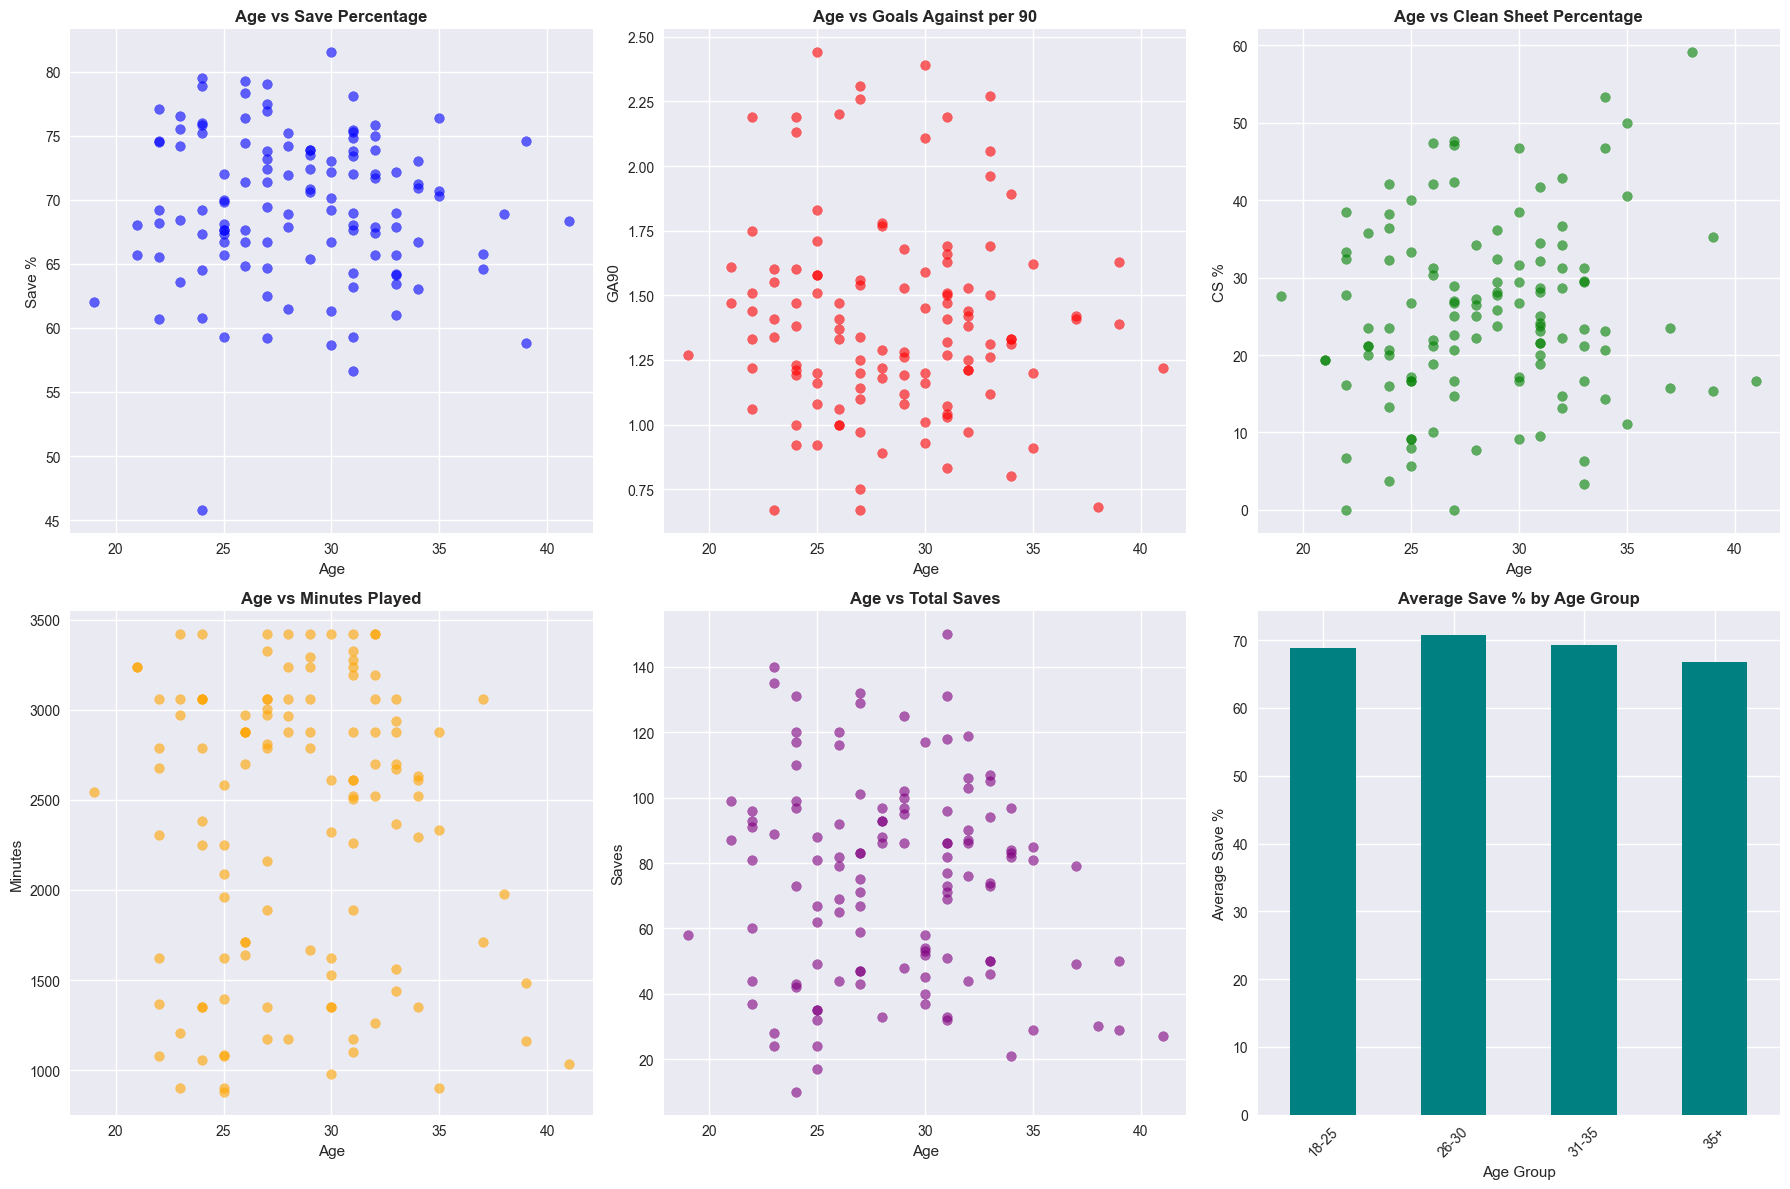


Correlation with Age:
Age      1.000000
Save%   -0.052437
GA90    -0.052970
CS%      0.134761
Min     -0.032659
Saves   -0.100436
Name: Age, dtype: float64


In [58]:
# Age vs Performance analysis
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
plt.scatter(qualified_gks['Age'], qualified_gks['Save%'], alpha=0.6, color='blue')
plt.title('Age vs Save Percentage', fontsize=12, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Save %')

plt.subplot(2, 3, 2)
plt.scatter(qualified_gks['Age'], qualified_gks['GA90'], alpha=0.6, color='red')
plt.title('Age vs Goals Against per 90', fontsize=12, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('GA90')

plt.subplot(2, 3, 3)
plt.scatter(qualified_gks['Age'], qualified_gks['CS%'], alpha=0.6, color='green')
plt.title('Age vs Clean Sheet Percentage', fontsize=12, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('CS %')

plt.subplot(2, 3, 4)
plt.scatter(qualified_gks['Age'], qualified_gks['Min'], alpha=0.6, color='orange')
plt.title('Age vs Minutes Played', fontsize=12, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Minutes')

plt.subplot(2, 3, 5)
plt.scatter(qualified_gks['Age'], qualified_gks['Saves'], alpha=0.6, color='purple')
plt.title('Age vs Total Saves', fontsize=12, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Saves')

plt.subplot(2, 3, 6)
age_groups = pd.cut(qualified_gks['Age'], bins=[18, 25, 30, 35, 50], labels=['18-25', '26-30', '31-35', '35+'])
age_performance = qualified_gks.groupby(age_groups)['Save%'].mean()
age_performance.plot(kind='bar', color='teal')
plt.title('Average Save % by Age Group', fontsize=12, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Average Save %')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Calculate correlation with age
age_correlations = qualified_gks[['Age', 'Save%', 'GA90', 'CS%', 'Min', 'Saves']].corr()['Age']
print("\nCorrelation with Age:")
print(age_correlations)

## 12. Market Value Analysis

Goalkeepers with market values: 140
Total goalkeepers: 206

=== TOP 10 MOST VALUABLE GOALKEEPERS ===
                   Player            Team Nation  Market_Value  Age  Save%  \
33             David Raya         Arsenal    ESP  40,00 mio. €   28   74.2   
145          Gregor Kobel        Dortmund    SUI  40,00 mio. €   26   66.7   
182  Gianluigi Donnarumma       Paris S-G    ITA  40,00 mio. €   25   67.6   
41      Guglielmo Vicario       Tottenham    ITA  32,00 mio. €   27   64.7   
40        Bart Verbruggen        Brighton    NED  30,00 mio. €   21   65.7   
65   Giorgi Mamardashvili        Valencia    GEO  30,00 mio. €   23   68.4   
176       Lucas Chevalier           Lille    FRA  30,00 mio. €   22   74.6   
78             Unai Simón   Athletic Club    ESP  28,00 mio. €   27   79.0   
25            André Onana  Manchester Utd    CMR  25,00 mio. €   28   68.9   
57            Joan García        Espanyol    ESP  25,00 mio. €   23   75.5   

      CS%  
33   34.2  
145  21.9  
182 

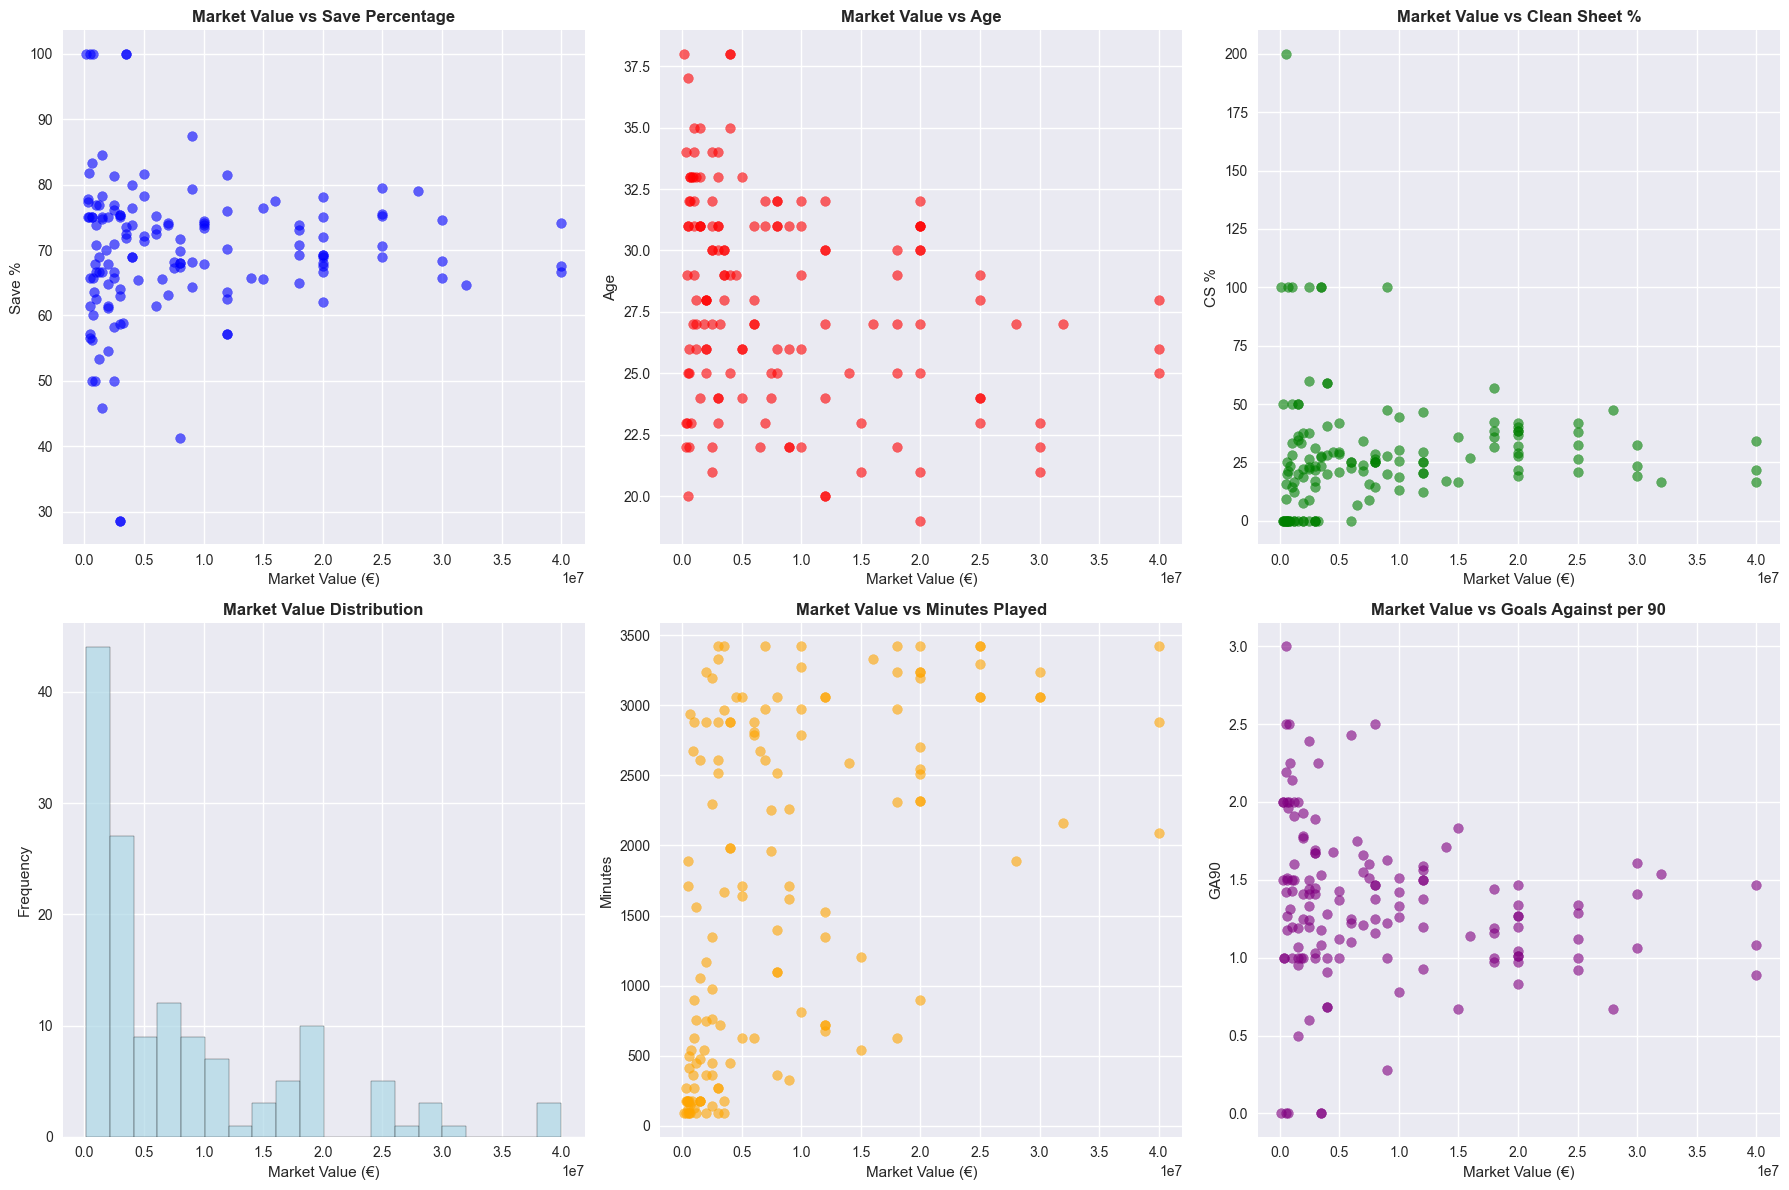


Correlation with Market Value:
Market_Value_Numeric    1.000000
Save%                   0.032185
GA90                   -0.175418
CS%                     0.035458
Age                    -0.286846
Min                     0.505322
Name: Market_Value_Numeric, dtype: float64


In [59]:
# Clean market values data
def clean_market_value(value):
    if pd.isna(value) or value == '-':
        return np.nan
    
    # Remove currency symbols and spaces
    value = str(value).replace('€', '').replace(' ', '')
    
    # Handle different formats
    if 'mio' in value:
        # Convert millions to numeric
        value = value.replace('mio.', '').replace(',', '.')
        return float(value) * 1000000
    elif 'K' in value:
        # Convert thousands to numeric
        value = value.replace('K', '')
        return float(value) * 1000
    else:
        return np.nan

market_values_df['Market_Value_Numeric'] = market_values_df['Market_Value'].apply(clean_market_value)

# Merge datasets on player names
merged_df = gk_df.merge(market_values_df, left_on='Player', right_on='Player_Name', how='left')

print(f"Goalkeepers with market values: {merged_df['Market_Value_Numeric'].notna().sum()}")
print(f"Total goalkeepers: {len(merged_df)}")

# Analyze market values for goalkeepers with values
gk_with_values = merged_df[merged_df['Market_Value_Numeric'].notna()].copy()

if len(gk_with_values) > 0:
    print("\n=== TOP 10 MOST VALUABLE GOALKEEPERS ===")
    top_valuable = gk_with_values.nlargest(10, 'Market_Value_Numeric')[
        ['Player', 'Team', 'Nation', 'Market_Value', 'Age', 'Save%', 'CS%']
    ]
    print(top_valuable)
    
    # Market value vs performance
    plt.figure(figsize=(18, 12))
    
    plt.subplot(2, 3, 1)
    plt.scatter(gk_with_values['Market_Value_Numeric'], gk_with_values['Save%'], alpha=0.6, color='blue')
    plt.title('Market Value vs Save Percentage', fontsize=12, fontweight='bold')
    plt.xlabel('Market Value (€)')
    plt.ylabel('Save %')
    
    plt.subplot(2, 3, 2)
    plt.scatter(gk_with_values['Market_Value_Numeric'], gk_with_values['Age'], alpha=0.6, color='red')
    plt.title('Market Value vs Age', fontsize=12, fontweight='bold')
    plt.xlabel('Market Value (€)')
    plt.ylabel('Age')
    
    plt.subplot(2, 3, 3)
    plt.scatter(gk_with_values['Market_Value_Numeric'], gk_with_values['CS%'], alpha=0.6, color='green')
    plt.title('Market Value vs Clean Sheet %', fontsize=12, fontweight='bold')
    plt.xlabel('Market Value (€)')
    plt.ylabel('CS %')
    
    plt.subplot(2, 3, 4)
    plt.hist(gk_with_values['Market_Value_Numeric'], bins=20, edgecolor='black', alpha=0.7, color='lightblue')
    plt.title('Market Value Distribution', fontsize=12, fontweight='bold')
    plt.xlabel('Market Value (€)')
    plt.ylabel('Frequency')
    
    plt.subplot(2, 3, 5)
    plt.scatter(gk_with_values['Market_Value_Numeric'], gk_with_values['Min'], alpha=0.6, color='orange')
    plt.title('Market Value vs Minutes Played', fontsize=12, fontweight='bold')
    plt.xlabel('Market Value (€)')
    plt.ylabel('Minutes')
    
    plt.subplot(2, 3, 6)
    plt.scatter(gk_with_values['Market_Value_Numeric'], gk_with_values['GA90'], alpha=0.6, color='purple')
    plt.title('Market Value vs Goals Against per 90', fontsize=12, fontweight='bold')
    plt.xlabel('Market Value (€)')
    plt.ylabel('GA90')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate correlation with market value
    value_correlations = gk_with_values[['Market_Value_Numeric', 'Save%', 'GA90', 'CS%', 'Age', 'Min']].corr()['Market_Value_Numeric']
    print("\nCorrelation with Market Value:")
    print(value_correlations)

## 13. Key Insights and Summary

In [60]:
# Summary statistics
print("=== SUMMARY STATISTICS ===")
print(f"Total number of goalkeepers: {len(gk_df)}")
print(f"Average age: {gk_df['Age'].mean():.1f} years")
print(f"Average save percentage: {gk_df['Save%'].mean():.1f}%")
print(f"Average goals against per 90: {gk_df['GA90'].mean():.2f}")
print(f"Average clean sheet percentage: {gk_df['CS%'].mean():.1f}%")
print(f"Total minutes played: {gk_df['Min'].sum():,.0f}")

print("\n=== TOP PERFORMING GOALKEEPERS ===")
print("Best Save Percentage:")
best_save = gk_df.loc[gk_df['Save%'].idxmax()]
print(f"{best_save['Player']} ({best_save['Team']}) - {best_save['Save%']:.1f}%")

print("\nBest Clean Sheet Percentage:")
best_cs = gk_df.loc[gk_df['CS%'].idxmax()]
print(f"{best_cs['Player']} ({best_cs['Team']}) - {best_cs['CS%']:.1f}%")

print("\nMost Minutes Played:")
most_minutes = gk_df.loc[gk_df['Min'].idxmax()]
print(f"{most_minutes['Player']} ({most_minutes['Team']}) - {most_minutes['Min']:,.0f} minutes")

print("\n=== AGE ANALYSIS ===")
age_groups = pd.cut(gk_df['Age'], bins=[18, 25, 30, 35, 50], labels=['18-25', '26-30', '31-35', '35+'])
age_distribution = gk_df.groupby(age_groups).size()
print("Age distribution:")
for age_group, count in age_distribution.items():
    print(f"{age_group}: {count} goalkeepers ({count/len(gk_df)*100:.1f}%)")

print("\n=== TEAM ANALYSIS ===")
print(f"Number of teams: {gk_df['Team'].nunique()}")
print(f"Number of nations: {gk_df['Nation'].nunique()}")

print("\nTeams with most goalkeepers:")
team_counts = gk_df['Team'].value_counts().head(5)
for team, count in team_counts.items():
    print(f"{team}: {count} goalkeepers")

print("\n=== PERFORMANCE INSIGHTS ===")
print(f"Average save percentage for qualified GKs (≥{min_matches} matches): {qualified_gks['Save%'].mean():.1f}%")
print(f"Average clean sheet percentage for qualified GKs: {qualified_gks['CS%'].mean():.1f}%")
print(f"Average goals against per 90 for qualified GKs: {qualified_gks['GA90'].mean():.2f}")

=== SUMMARY STATISTICS ===
Total number of goalkeepers: 201
Average age: 27.9 years
Average save percentage: 68.3%
Average goals against per 90: 1.50
Average clean sheet percentage: 25.5%
Total minutes played: 313,308

=== TOP PERFORMING GOALKEEPERS ===
Best Save Percentage:
Aitor Fernández (Osasuna) - 100.0%

Best Clean Sheet Percentage:
Frank Feller (Heidenheim) - 200.0%

Most Minutes Played:
Dean Henderson (Crystal Palace) - 3,420 minutes

=== AGE ANALYSIS ===
Age distribution:
18-25: 67 goalkeepers (33.3%)
26-30: 64 goalkeepers (31.8%)
31-35: 60 goalkeepers (29.9%)
35+: 9 goalkeepers (4.5%)

=== TEAM ANALYSIS ===
Number of teams: 96
Number of nations: 51

Teams with most goalkeepers:
Tottenham: 4 goalkeepers
Bournemouth: 3 goalkeepers
Wolves: 3 goalkeepers
Leicester City: 3 goalkeepers
Southampton: 3 goalkeepers

=== PERFORMANCE INSIGHTS ===
Average save percentage for qualified GKs (≥10 matches): 69.5%
Average clean sheet percentage for qualified GKs: 25.3%
Average goals against p